# Исследовательский анализ пользовательских предпочтений сервиса Яндекс Афиша

- Автор: Самонов Иван
- Дата: 09.06.2026

***Цели проекта:***
1. Выявить причины изменения пользовательских предпочтений и популярности событий осенью 2024 года
2. Проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами

***Задачи проекта:***
1. Провести исследовательский анализ данных
2. Провести статистический анализ данных

## Описание данных

1. `final_tickets_orders_df.csv` - содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных

`order_id` — уникальный идентификатор заказа.<br>
`user_i` — уникальный идентификатор пользователя.<br>
`created_dt_msk` — дата создания заказа (московское время).<br>
`created_ts_msk` — дата и время создания заказа (московское время).<br>
`event_id` — идентификатор мероприятия из таблицы events.<br>
`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.<br>
`age_limit` — возрастное ограничение мероприятия.<br>
`currency_code` — валюта оплаты, например rub для российских рублей.<br>
`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.<br>
`revenue` — выручка от заказа.<br>
`service_name` — название билетного оператора.<br>
`tickets_count` — количество купленных билетов.<br>
`total` — общая сумма заказа.<br>
`days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

2. `final_tickets_events_df` - содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия

`event_id` — уникальный идентификатор мероприятия.<br>
`event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.<br>
`event_type_description` — описание типа мероприятия.<br>
`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.<br>
`organizers` — организаторы мероприятия.<br>
`region_name` — название региона.<br>
`city_name` — название города.<br>
`venue_id` — уникальный идентификатор площадки.<br>
`venue_name` — название площадки.<br>
`venue_address` — адрес площадки.

3. `final_tickets_tenge_df.csv` - содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге

`nominal` — номинал (100 тенге).<br>
`data` — дата.<br>
`curs` — курс тенге к рублю.<br>
`cdx` — обозначение валюты (kzt).

## Содержание:

<a class = 'anchor' id = '6-bullet'></a>
- [Шаг 1. Загрузка данных](#1-bullet)
- [Шаг 2. Предобработка данных](#2-bullet)
- [Шаг 3. Исследовательский анализ данных](#3-bullet)
- [Шаг 4. Статистический анализ данных](#4-bullet)
- [Шаг 5. Общий вывод и рекомендации](#5-bullet)

<a class = 'anchor' id = '1-bullet'></a>
### Шаг 1. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
orders_df = pd.read_csv('final_tickets_orders_df.csv')
events_df = pd.read_csv('final_tickets_events_df.csv')
tenge_df = pd.read_csv('final_tickets_tenge_df.csv')

In [3]:
orders_df.info()
orders_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
events_df.info()
events_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
tenge_df.info()
tenge_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


**Промежуточный вывод:** данные соответствуют описанию. Пропуски есть только в столбце `days_since_prev` таблицы `orders_df`. В таблице orders_df нужно оптимизировать типы данных. Столбцы `created_dt_msk` и `created_ts_msk` лучше привести к типу timestamp и datetime64 соответственно. Так же столбец `data` таблицы `tenge_df` лучше привести к типу timestamp. В остальных столбцах типы данных корректные

[Назад к содержанию](#6-bullet)

<a class = 'anchor' id = '2-bullet'></a>
### Шаг 2. Предобработка данных

#### Объединение данных

In [6]:
df = orders_df.merge(events_df, how='inner', on='event_id').merge(tenge_df, how='inner', left_on='created_dt_msk', right_on='data')
df_copy = df.copy()

Столбец `data` полностью дублирует значения столбца `created_dt_msk`, поэтому его можно удалить

In [7]:
df.drop(columns=['data'], inplace=True)

#### Проверка на пропуски

In [8]:
print(f"Количество пропусков: {df['event_name'].isna().sum()}")
print(f"Относильное выражение: {round((df['event_name'].isna().sum() / df.shape[0])*100, 2)}%")

Количество пропусков: 0
Относильное выражение: 0.0%


После объединения таблиц пропуски остались только в столбце `days_since_prev`, что соответствует заданию

#### Проверка категориальных данных

In [9]:
print('Количество уникальных значений в столбце:')
for column in ['device_type_canonical', 'region_name', 'city_name',
               'venue_name', 'service_name', 'event_type_description', 
               'event_type_main', 'organizers']:
    print(f"{column} - {df[column].nunique()}")

Количество уникальных значений в столбце:
device_type_canonical - 2
region_name - 81
city_name - 352
venue_name - 3217
service_name - 36
event_type_description - 20
event_type_main - 7
organizers - 4293


Проверим оставшиеся столбцы, где не так много категорий:

In [10]:
for column in ['device_type_canonical', 'region_name', 'service_name', 
               'event_type_description', 'event_type_main']:
    print(column)
    print(df[column].sort_values().unique(), '\n')

device_type_canonical
['desktop' 'mobile'] 

region_name
['Белоярская область' 'Берестовский округ' 'Берёзовская область'
 'Боровлянский край' 'Верховинская область' 'Верхозёрский край'
 'Верхоречная область' 'Ветренский регион' 'Вишнёвский край'
 'Глиногорская область' 'Голубевский округ' 'Горицветская область'
 'Горноземский регион' 'Горностепной регион' 'Дальнеземская область'
 'Дальнезорский край' 'Дубравная область' 'Залесский край'
 'Заречная область' 'Зеленоградский округ' 'Златопольский округ'
 'Золотоключевской край' 'Зоринский регион' 'Каменевский регион'
 'Каменичская область' 'Каменноозёрный край' 'Каменноярский край'
 'Каменополянский округ' 'Ключеводский округ' 'Кристаловская область'
 'Кристальная область' 'Крутоводская область' 'Крутоводский регион'
 'Лесноярский край' 'Лесодальний край' 'Лесополянская область'
 'Лесостепной край' 'Лесоярская область' 'Луговая область'
 'Лугоградская область' 'Малиновая область' 'Малиновоярский округ'
 'Медовская область' 'Миропольская 

В столбцах корректные категории

#### Проверка количественных значений

Распределения в столбцах для рублей:
revenue


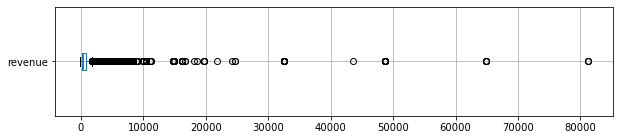

tickets_count


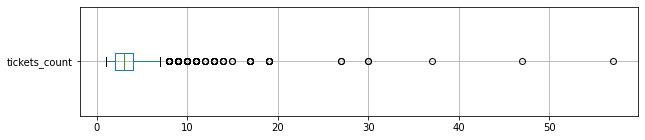

total


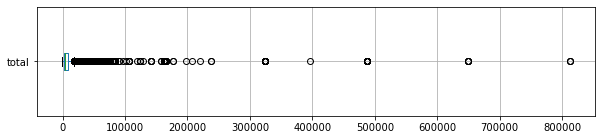

In [11]:
print('Распределения в столбцах для рублей:')
df_rub = df[df['currency_code'] == 'rub']
for value in ['revenue', 'tickets_count', 'total']:
    print(value)
    df_rub.boxplot(
        column=value, 
        vert=False,
        figsize=(10, 2))
    plt.show()

Распределения в столбцах для тенге:
revenue


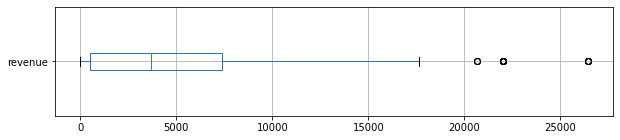

tickets_count


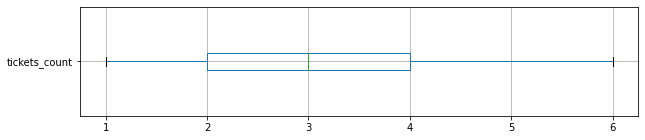

total


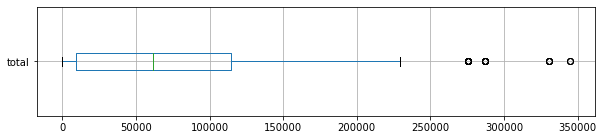

In [12]:
print('Распределения в столбцах для тенге:')
df_kzt = df[df['currency_code'] == 'kzt']
for value in ['revenue', 'tickets_count', 'total']:
    print(value)
    df_kzt.boxplot(
        column=value, 
        vert=False,
        figsize=(10, 2))
    plt.show()

В столбцах `revenue` и `tickets_count` присутствуют крупные выбросы. Оставим данные только до 99го процентиля в столбце `revenue`:

In [13]:
df = df[df['revenue'] <= df['revenue'].quantile(0.99)]

#### Проверка неявных дубликатов

Считаем число неявных дубликатов (без учета столбца `order_id`)

In [14]:
f"Число неявных дубликатов: {df.duplicated(subset=df.columns.drop(['order_id'])).sum()}"

'Число неявных дубликатов: 30'

Дубликатов немного, удалим их:

In [15]:
df.drop_duplicates(subset=df.columns.drop(['order_id']), inplace=True)

#### Преобразование типов данных

Приведем столбцы `created_dt_msk` и `created_ts_msk` к типу datetime

In [16]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

#### Создание новых столбцов

In [17]:
# revenue_rub
def kzt_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    else:
        return row['revenue'] * row['curs'] / 100
df['revenue_rub'] = df.apply(kzt_to_rub, axis=1)

In [18]:
# one_ticket_revenue_rub
df['one_ticket_revenue_rub'] = df['revenue'] / df['tickets_count']

In [19]:
# month
df['month'] = df['created_dt_msk'].dt.month
df['month'].sort_values().unique()

array([ 6,  7,  8,  9, 10], dtype=int64)

In [20]:
# season
# В данных представлены события только за лето и осень
def season_name(row):
    if row['month'] in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'
df['season'] = df.apply(season_name, axis=1)

**Выводы после предобработки:**

In [21]:
print(f"Строк отброшено: {df_copy.shape[0] - df.shape[0]}")
print(f"Относильное выражение: {round((df_copy.shape[0] - df.shape[0]) / df_copy.shape[0], 2)}%")

Строк отброшено: 2937
Относильное выражение: 0.01%


Добавлены столбцы: 
- `revenue_rub` - выручка в рублях
- `one_ticket_revenue_rub` - выручка с одного билета в заказе
- `month` - номер месяца 
- `season` - название сезона 

[Назад к содержанию](#6-bullet)

<a class = 'anchor' id = '3-bullet'></a>
### Шаг 3. Исследовательский анализ данных

#### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

<AxesSubplot:title={'center':'Количество заказов по месяцам'}, xlabel='Номер месяца', ylabel='Количество заказов'>

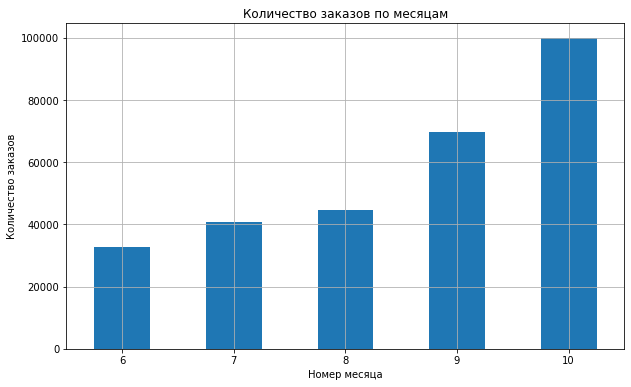

In [22]:
df.groupby('month')['order_id'].count().plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0,
    title='Количество заказов по месяцам',
    xlabel='Номер месяца',
    ylabel='Количество заказов')

С июня по ноябрь 2024 года действительно наблюдается рост числа заказов

<AxesSubplot:title={'center':'Сравнение долей количества заказов по сезонам в разрезе типа мероприятия'}, xlabel='Тип мероприятия', ylabel='Доля заказов'>

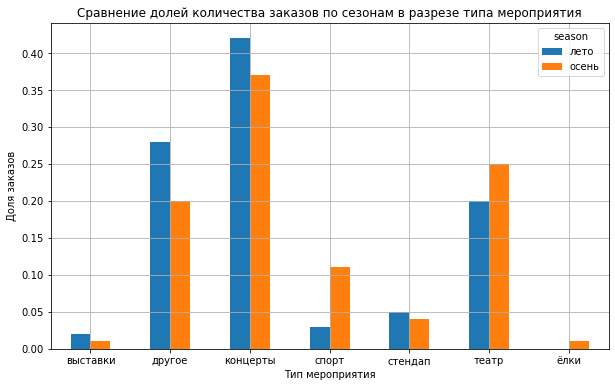

In [23]:
counts = df.groupby(['season', 'event_type_main'])['order_id'].count()
season_totals = counts.groupby(level=0).transform('sum')
data_plot_event_type = (counts / season_totals).round(2).unstack(0)
data_plot_event_type.plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0,
    title='Сравнение долей количества заказов по сезонам в разрезе типа мероприятия',
    xlabel='Тип мероприятия',
    ylabel='Доля заказов')

<AxesSubplot:title={'center':'Сравнение долей количества заказов по сезонам в разрезе типа устройства'}, xlabel='Тип устройства', ylabel='Доля заказов'>

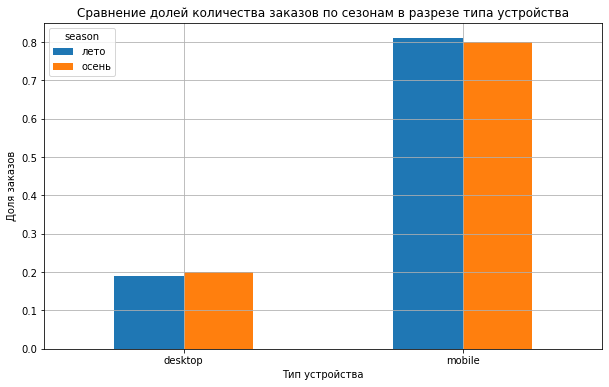

In [24]:
counts = df.groupby(['season', 'device_type_canonical'])['order_id'].count()
season_totals = counts.groupby(level=0).transform('sum')
data_plot_device_type = (counts / season_totals).round(2).unstack(0)
data_plot_device_type.plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0,
    title='Сравнение долей количества заказов по сезонам в разрезе типа устройства',
    xlabel='Тип устройства',
    ylabel='Доля заказов')

<AxesSubplot:title={'center':'Сравнение долей количества заказов по сезонам в разрезе возрастного рейтинга'}, xlabel='Возрастной рейтинг', ylabel='Доля заказов'>

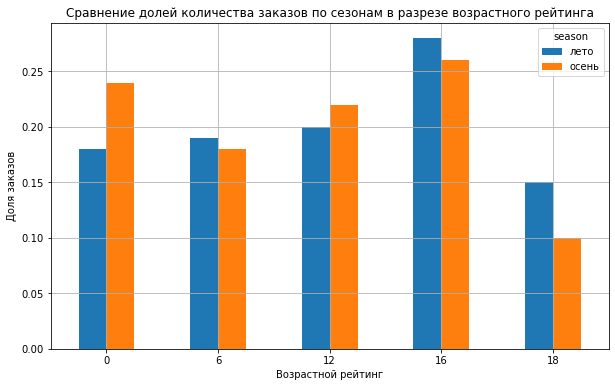

In [25]:
counts = df.groupby(['season', 'age_limit'])['order_id'].count()
season_totals = counts.groupby(level=0).transform('sum')
data_plot_age_limit = (counts / season_totals).round(2).unstack(0)
data_plot_age_limit.plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0,
    title='Сравнение долей количества заказов по сезонам в разрезе возрастного рейтинга',
    xlabel='Возрастной рейтинг',
    ylabel='Доля заказов')

In [26]:
data_plot_avg = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack(0)
data_plot_avg['изменение_доля'] = (data_plot_avg['осень'] / data_plot_avg['лето']).round(2)
data_plot_avg

season,лето,осень,изменение_доля
event_type_main,,,
выставки,86.416198,91.066619,1.05
другое,82.888450,81.052111,0.98
концерты,323.256923,276.876510,0.86
спорт,56.390602,53.954273,0.96
стендап,221.284353,232.626359,1.05
театр,218.726550,179.696929,0.82
ёлки,274.749549,234.216151,0.85


<AxesSubplot:title={'center':'Сравнение средней выручки с продажи одного билета по сезонам в разрезе типа мероприятия'}, xlabel='Тип мероприятия', ylabel='Средняя выручка с одного билета'>

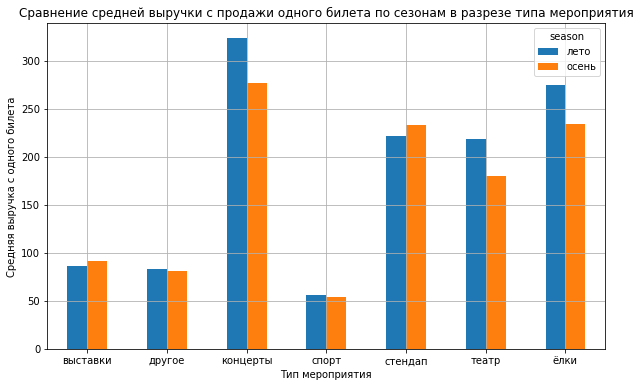

In [27]:
data_plot_avg[['лето', 'осень']].plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0,
    title='Сравнение средней выручки с продажи одного билета по сезонам в разрезе типа мероприятия',
    xlabel='Тип мероприятия',
    ylabel='Средняя выручка с одного билета')

**Промежуточный вывод:** с наступление осени наблюдается спад количества заказов в категориях мероприятий "другое", "концерты" и выставки. Рост наблюдается в категориях "спорт", "елки" и театр. Количество заказов в разрезе типа устройства не меняется с измением сезона. Осенью повышается число заказов в возрастном рейтинге "0" и "12", но падает в остальных. Средняя стоимость одного билета уменьшается в категории "концерты", "театр" и "елки". В остальных категориях она практически не меняется.

#### 3.2. Осенняя активность пользователей

In [28]:
# Подготовка данных
data_day = df[df['season'] == 'осень'].groupby('created_dt_msk').agg({'order_id': 'count', 'user_id': 'nunique', 'one_ticket_revenue_rub': 'mean'})
data_day.columns = ['order_count', 'unique_users', 'avg_tiket_revenue']
data_day['avg_user_orders'] = (data_day['order_count'] / data_day['unique_users']).round(2)
data_day['avg_tiket_revenue'] = data_day['avg_tiket_revenue'].round(2)
data_day = data_day.reset_index()

<AxesSubplot:title={'center':'Динамика общего числа заказов осень по дням'}, xlabel='Дата', ylabel='Число заказов'>

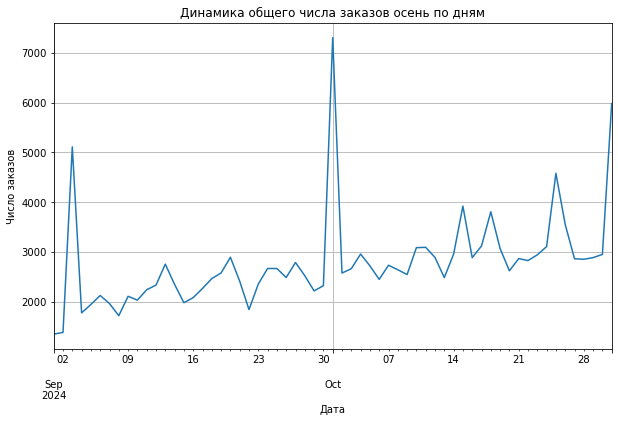

In [29]:
data_day.plot(
    x='created_dt_msk',
    y='order_count',
    figsize=(10, 6),
    grid=True,
    legend=False,
    title='Динамика общего числа заказов осень по дням',
    ylabel='Число заказов',
    xlabel='Дата')

<AxesSubplot:title={'center':'Динамика количества уникальных активных пользователей осенью по дням'}, xlabel='Дата', ylabel='Количество уникальных пользователей'>

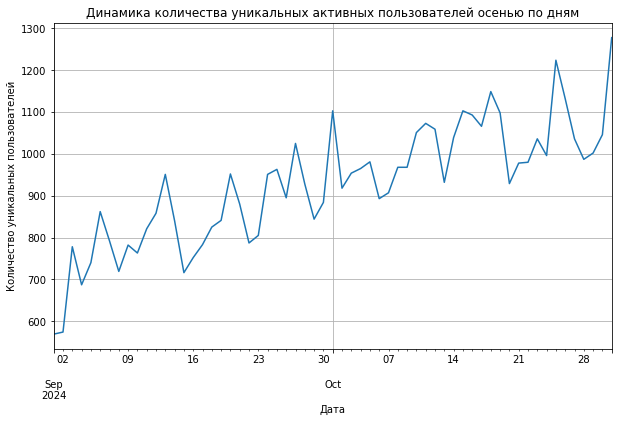

In [30]:
data_day.plot(
    x='created_dt_msk',
    y='unique_users',
    figsize=(10, 6),
    grid=True,
    legend=False,
    title='Динамика количества уникальных активных пользователей осенью по дням',
    ylabel='Количество уникальных пользователей',
    xlabel='Дата')

<AxesSubplot:title={'center':'Динамика среднего числа заказов на одного пользователя осенью по дням'}, xlabel='Дата', ylabel='Среднее число заказов на одного пользователя'>

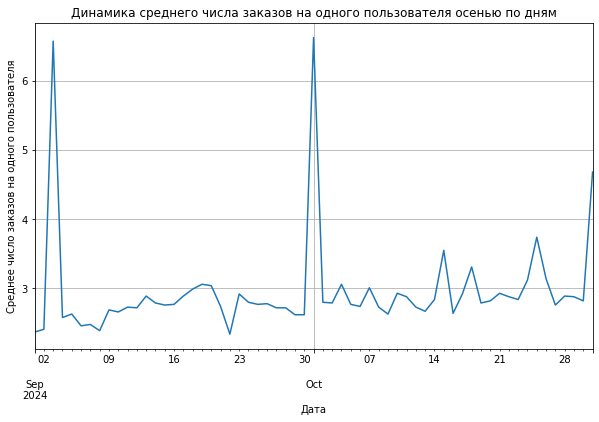

In [31]:
data_day.plot(
    x='created_dt_msk',
    y='avg_user_orders',
    figsize=(10, 6),
    grid=True,
    legend=False,
    title='Динамика среднего числа заказов на одного пользователя осенью по дням',
    ylabel='Среднее число заказов на одного пользователя',
    xlabel='Дата')

<AxesSubplot:title={'center':'Динамика средней стоимости одного билета осенью по дням'}, xlabel='Дата', ylabel='Средняя стоимость одного билета'>

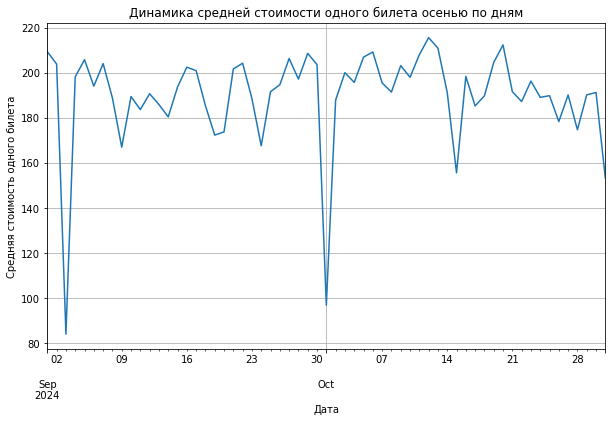

In [32]:
data_day.plot(
    x='created_dt_msk',
    y='avg_tiket_revenue',
    figsize=(10, 6),
    grid=True,
    legend=False,
    title='Динамика средней стоимости одного билета осенью по дням',
    ylabel='Средняя стоимость одного билета',
    xlabel='Дата')

In [33]:
# Создание бинарного признака для дня недели
df_dayweek = df[['created_dt_msk', 'user_id']].copy()
df_dayweek['day_of_week'] = df_dayweek['created_dt_msk'].dt.dayofweek
df_dayweek['weekend'] = df_dayweek['day_of_week'] >= 5

<AxesSubplot:title={'center':'Сравнение количества уникальных пользователей в будни и выходные'}, xlabel='Тип дня недели', ylabel='Количество уникальных пользователей'>

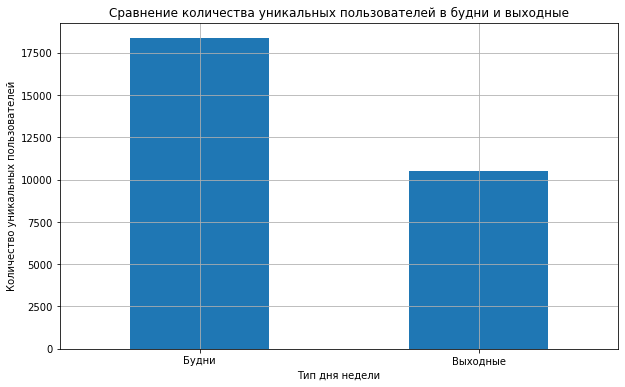

In [34]:
data_user_dayweek = df_dayweek.groupby('weekend')['user_id'].nunique().reset_index()
data_user_dayweek['day_type'] = data_user_dayweek['weekend'].map({False: 'Будни', True: 'Выходные'})
data_user_dayweek.plot(
    kind='bar',
    x='day_type',
    y='user_id',
    figsize=(10, 6),
    grid=True,
    rot=0,
    legend=False,
    title='Сравнение количества уникальных пользователей в будни и выходные',
    xlabel='Тип дня недели',
    ylabel='Количество уникальных пользователей')

**Промежуточный вывод:** с сентября наблюдается рост общего числа заказов и количества уникальных пользователей. Важно обратить внимание на рост числа уникальных пользователей. Он скорее всего указывает на приход новых клиентов в сервис, а это в свою очередь может объяснять рост суммарной выручки сервиса осенью. Так же количество уникальных пользователей больше в будни дни почти в два раза по сравнению с выходными.

#### 3.3. Популярные события и партнёры

**Топ-10 регионов по количеству уникальных мероприятий**

In [35]:
data_region = df.groupby('region_name').agg({'event_id': 'nunique', 'order_id': 'count'}).reset_index()
data_region.columns = ['Название региона', 'Уникальное количество мероприятий', 'Общее число заказов']
data_region['Доля мероприятий от общего числа'] = (data_region['Уникальное количество мероприятий'] / df['event_id'].nunique()).round(2)
data_region = data_region.sort_values('Уникальное количество мероприятий', ascending=False).head(10)
data_region

,Название региона,Уникальное количество мероприятий,Общее число заказов,Доля мероприятий от общего числа
23,Каменевский регион,5966,90669,0.27
60,Североярская область,3809,43966,0.17
77,Широковская область,1233,16446,0.06
57,Светополянский округ,1075,7575,0.05
52,Речиновская область,702,6290,0.03
74,Травяная область,683,5042,0.03
11,Горицветская область,551,5162,0.02
61,Серебринская область,541,5608,0.02
78,Яблоневская область,535,6173,0.02
69,Тепляковская область,529,4387,0.02


<AxesSubplot:title={'center':'Топ-10 регионов по числу уникальных мероприятий'}>

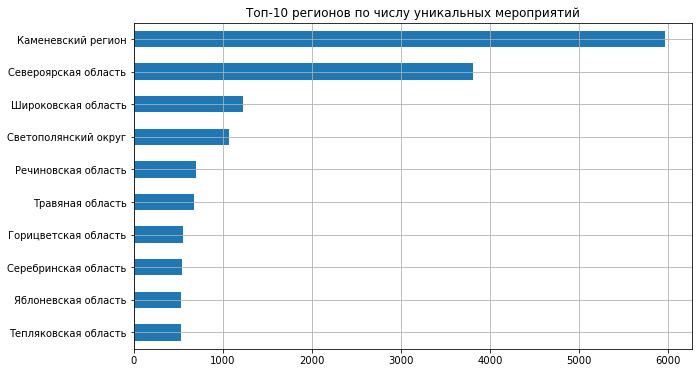

In [36]:
data_region.sort_values('Уникальное количество мероприятий').plot(
    kind='barh',
    x='Название региона',
    y='Уникальное количество мероприятий',
    figsize=(10, 6),
    grid=True,
    rot=0,
    legend=False,
    title='Топ-10 регионов по числу уникальных мероприятий',
    xlabel='')

**Топ-10 билетных партнеров по количеству уникальных мероприятий**

In [37]:
data_service = df.groupby('service_name').agg({'event_id': 'nunique', 'order_id': 'count', 'revenue': 'sum'}).reset_index()
data_service.columns = ['Название партнера', 'Уникальное количество мероприятий', 'Общее число заказов', 'Суммарная выручка']
data_service['Доля мероприятий от общего числа'] = (data_service['Уникальное количество мероприятий'] / df['event_id'].nunique()).round(2)
data_service = data_service.sort_values('Уникальное количество мероприятий', ascending=False).head(10)
data_service

,Название партнера,Уникальное количество мероприятий,Общее число заказов,Суммарная выручка,Доля мероприятий от общего числа
21,Лови билет!,4878,41104,17573375.71,0.22
3,Билеты без проблем,4253,63105,26164578.42,0.19
5,Билеты в руки,3536,40330,13341168.49,0.16
25,Облачко,2343,26557,19041296.87,0.10
22,Лучшие билеты,1762,17769,2810506.81,0.08
24,Мой билет,1305,32753,21513122.66,0.06
30,Тебе билет!,1062,5225,3065264.71,0.05
26,Прачечная,1027,10273,4900985.27,0.05
8,Весь в билетах,864,16728,17433448.77,0.04
35,Яблоко,715,5038,3966818.61,0.03


<AxesSubplot:title={'center':'Топ-10 билетных партнеров по числу уникальных мероприятий'}>

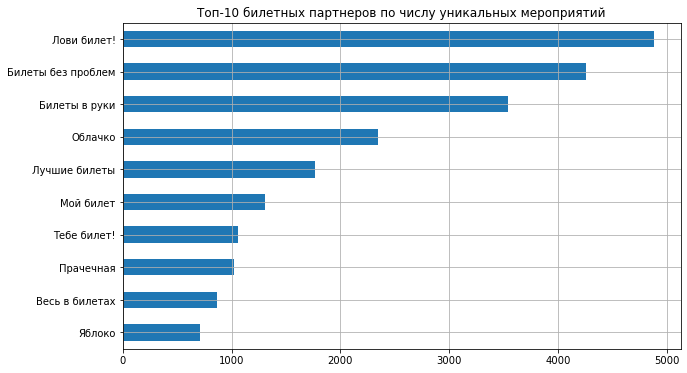

In [38]:
data_service.sort_values('Уникальное количество мероприятий').plot(
    kind='barh',
    x='Название партнера',
    y='Уникальное количество мероприятий',
    figsize=(10, 6),
    grid=True,
    rot=0,
    legend=False,
    title='Топ-10 билетных партнеров по числу уникальных мероприятий',
    xlabel='')

**Промежуточный вывод:** самые популярные регионы по числу уникальных мероприятий Каменевский регион и Североярская область, в них проводились 27% и 17% общего числа мероприятий соответственно. Самые популярные сервисы билетов: "Лови билет!", "Билеты без проблем" и "Билеты в руки" вместе проводят почти 60% от общего числа мероприятий. 

[Назад к содержанию](#6-bullet)

<a class = 'anchor' id = '4-bullet'></a>
### Шаг 4. Статистический анализ данных

#### 4.1 Проверка 1-ой гипотезы

"Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств"

Выделяем группы пользователей

In [39]:
group_mobile = df[
    (df['device_type_canonical'] == 'mobile') & 
    (df['season'] == 'осень')
].groupby('user_id')['order_id'].count().reset_index()
group_mobile.columns = ['user_id', 'orders_count']

In [40]:
group_desktop = df[
    (df['device_type_canonical'] == 'desktop') & 
    (df['season'] == 'осень')
].groupby('user_id')['order_id'].count().reset_index()
group_desktop.columns = ['user_id', 'orders_count']

Проверка размеров выборок

In [41]:
print(f"Размер выборки group_mobile: {group_mobile.shape[0]}")
print(f"Размер выборки group_desktop: {group_desktop.shape[0]}")

Размер выборки group_mobile: 14195
Размер выборки group_desktop: 4883


Проверка пересечения выборок

In [42]:
cross_user_id = list(set(group_mobile['user_id']) & set(group_desktop['user_id']))
f"{len(cross_user_id)} пользователей попали в обе группы"

'3259 пользователей попали в обе группы'

Расчет среднего

In [43]:
print(f"Среднее количество заказов на пользователя в group_desktop: {round(group_desktop['orders_count'].mean(), 2)}")
print(f"Среднее количество заказов на пользователя в group_mobile: {round(group_mobile['orders_count'].mean(), 2)}")

Среднее количество заказов на пользователя в group_desktop: 7.08
Среднее количество заказов на пользователя в group_mobile: 9.51


Расчет дисперсии выборок

In [44]:
print(f"Дисперсия выборки group_desktop: {round(group_desktop['orders_count'].var(), 2)}")
print(f"Дисперсия выборки group_mobile: {round(group_mobile['orders_count'].var(), 2)}")

Дисперсия выборки group_desktop: 1312.39
Дисперсия выборки group_mobile: 4684.24


- **Нулевая гипотеза:** среднее количество заказов на одного пользователя мобильного приложения не превышает среднее количество заказов на одного пользователя стационарных приложения.


- **Альтернативная гипотеза:** cреднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [45]:
# Используем тест Уэлча
alpha = 0.05
result = ttest_ind(
    group_desktop['orders_count'],
    group_mobile['orders_count'],
    equal_var=False,
    alternative='less')
if result.pvalue > alpha:
    print(f"p-value: {result.pvalue}")
    print(f"Нулевая гипотеза находит подтверждение, средние в выборке group_mobile не превышает среднее выборки group_desktop.")
else: 
    print(f"p-value: {result.pvalue}")
    print(f"Нулевая гипотеза не находит подтверждение, средние в выборке group_mobile больше.")

p-value: 0.0008235613775194347
Нулевая гипотеза не находит подтверждение, средние в выборке group_mobile больше.


**Промежуточный вывод:** по результатам теста было получено p-value равное 0.0008235613775194347. Это значение меньше установленного уровня значимости в 0.05. Статистически получилось доказать, что среднее количество заказов на одного пользователя мобильного приложения выше среднего пользователей стационарных устройств. Получается что пользователи мобильных приложений в среднем делают больше заказов.

#### 4.2 Проверка 2-ой гипотезы

"Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств."

Выделяем группы пользователей

Пользователи мобильных устройств:

In [46]:
# Считаем время между заказами конкретного пользователя
group_mobile = df[
    (df['device_type_canonical'] == 'mobile') & 
    (df['season'] == 'осень')
].sort_values(['user_id', 'created_ts_msk'])[['user_id', 'created_ts_msk']].copy()
group_mobile['created_ts_msk_prev'] = group_mobile.groupby('user_id')['created_ts_msk'].shift(1)
group_mobile['time_bet_orders'] = (group_mobile['created_ts_msk'] - group_mobile['created_ts_msk_prev']).dt.total_seconds()
group_mobile = group_mobile.dropna(subset=['time_bet_orders'])

In [47]:
# Считаем среднее время между заказами у конкретного пользователя
group_mobile = group_mobile.groupby('user_id')['time_bet_orders'].mean().reset_index()
group_mobile.columns = ['user_id', 'avg_time_bet_orders']

Пользователи стационарных устройств:

In [48]:
# Считаем время между заказами конкретного пользователя
group_desktop = df[
    (df['device_type_canonical'] == 'desktop') & 
    (df['season'] == 'осень')
].sort_values(['user_id', 'created_ts_msk'])[['user_id', 'created_ts_msk']].copy()
group_desktop['created_ts_msk_prev'] = group_desktop.groupby('user_id')['created_ts_msk'].shift(1)
group_desktop['time_bet_orders'] = (group_desktop['created_ts_msk'] - group_desktop['created_ts_msk_prev']).dt.total_seconds()
group_desktop = group_desktop.dropna(subset=['time_bet_orders'])

In [49]:
# Считаем среднее время между заказами у конкретного пользователя
group_desktop = group_desktop.groupby('user_id')['time_bet_orders'].mean().reset_index()
group_desktop.columns = ['user_id', 'avg_time_bet_orders']

Проверка размера выборок

In [50]:
print(f"Размер выборки group_mobile: {group_mobile.shape[0]}")
print(f"Размер выборки group_desktop: {group_desktop.shape[0]}")

Размер выборки group_mobile: 8273
Размер выборки group_desktop: 2717


Проверка пересечения выборок

In [51]:
cross_user_id = list(set(group_mobile['user_id']) & set(group_desktop['user_id']))
f"{len(cross_user_id)} пользователей попали в обе группы"

'1899 пользователей попали в обе группы'

In [52]:
# удалим пользователей, которые попали в обе выборки
group_mobile = group_mobile[~group_mobile['user_id'].isin(cross_user_id)]
group_desktop = group_desktop[~group_desktop['user_id'].isin(cross_user_id)]

In [53]:
print(f"Среднее время между заказами в group_desktop: {round(group_desktop['avg_time_bet_orders'].mean(), 2)}")
print(f"Среднее время между заказами в group_mobile: {round(group_mobile['avg_time_bet_orders'].mean(), 2)}")

Среднее время между заказами в group_desktop: 364009.81
Среднее время между заказами в group_mobile: 584960.91


Расчет дисперсии выборок

In [54]:
print(f"Дисперсия выборки group_desktop: {round(group_desktop['avg_time_bet_orders'].var(), 2)}")
print(f"Дисперсия выборки group_mobile: {round(group_mobile['avg_time_bet_orders'].var(), 2)}")

Дисперсия выборки group_desktop: 616182942356.94
Дисперсия выборки group_mobile: 634589780151.43


- **Нулевая гипотеза:** среднее время между заказами пользователей мобильных приложений не превышает среднее время между заказами пользователей стационарных устройств.


- **Альтернативная гипотеза:** среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Выборочные дисперсии приближенно равны - используем тест тест Стьюдента

In [55]:
alpha = 0.05
result = ttest_ind(
    group_desktop['avg_time_bet_orders'],
    group_mobile['avg_time_bet_orders'],
    alternative='less')
if result.pvalue > alpha:
    print(f"p-value: {result.pvalue}")
    print(f"Нулевая гипотеза находит подтверждение, среднее в выборке group_mobile не превышает среднее выборки group_desktop.")
else: 
    print(f"p-value: {result.pvalue}")
    print(f"Нулевая гипотеза не находит подтверждение, среднее в выборке group_mobile больше.")

p-value: 4.144790696125702e-14
Нулевая гипотеза не находит подтверждение, среднее в выборке group_mobile больше.


**Промежуточный вывод:** по результатам теста было получено p-value равное 4.144790696125702e-14. Это значение меньше установленного уровня значимости в 0.05. Статистически получилось доказать, что среднее время между заказами пользователей мобильных приложений превышает среднее время между заказами пользователей стационарных устройств. Предположительно пользователи десктопных версий быстрее и охотнее возвращаются за повторными заказами

[Назад к содержанию](#6-bullet)

<a class = 'anchor' id = '5-bullet'></a>
### Шаг 5. Общий вывод и рекомендации

- Полученные данных были очищены от дубликатов. Были преобразованы типы дат и добавлены новые столбцы (перечень добавленных столбцов указан в разделе с предобработкой данных). В данных осталось 287674 строк и 31 столбец. Отброшено 0.01% данных после предобработки.
- С сентября наблюдается рост общего числа заказов, средний чек при этом практически не изменялся. По результатам анализа пользовательской активности выяснилось, что с сенября наблюдался рост числа уникальных клиент (приток новых клиентов). Скорее всего именно это стало причиной роста общей выручки осенью. Осенью повысился спрос на мероприятия типа "спорт", "театр" и "Елки". А так же на мероприятия с возрастным ограничением "0". Каменевский регион и Североярская область явные лидеры по числу проводимых мероприятий. Они провели 27% и 17% от общего числа мероприятий соответственно
- По результатам проверки гипотез можно заметить, что пользователи мобильных приложений делают больше заказов. При этом пользователи стационарных устройств совершают заказы чаще.